# K-Nearest Neighbors (KNN)

## Setup and Imports

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, log_loss
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

## Data Preprocessing

### Load the data

In [56]:
train_df = pd.read_csv('data/splits/TRAIN_LJ_Dataset.csv')
val_df = pd.read_csv('data/splits/VALID_LJ_Dataset.csv')
test_df = pd.read_csv('data/splits/TEST_LJ_Dataset.csv')

train_df.head()

,Date,Age,Home,HSG,PPG3,3PA3,3P%3,FGA3,FG%3,FTA3,FT%3,MP3
0,2003-11-05,18.849315,1,0,18.000,2.667,0.067,16.333,0.440,4.000,0.635,40.783
1,2003-11-07,18.854795,0,0,12.000,2.667,0.067,13.333,0.331,3.333,0.857,40.206
2,2003-11-08,18.857534,1,0,12.667,1.667,0.167,13.667,0.322,3.333,0.952,41.333
3,2003-11-10,18.863014,1,0,15.667,1.333,0.167,16.000,0.379,4.000,0.702,43.111
4,2003-11-12,18.868493,0,0,19.000,1.667,0.500,16.333,0.483,3.667,0.369,40.628


### Separate features and target

We drop `Date` as it is just an identifier and not a useful feature for the model.
`HSG` is separated as the target variable.

In [57]:
X_train = train_df.drop(columns=['Date', 'HSG'])
y_train = train_df['HSG']
X_val = val_df.drop(columns=['Date', 'HSG'])
y_val = val_df['HSG']
X_test = test_df.drop(columns=['Date', 'HSG'])
y_test = test_df['HSG']

print(f"Dataset Information:")
print(f"  Train: {len(y_train)} samples | Val: {len(y_val)} samples | Test: {len(y_test)} samples")
print(f"  Features: {X_train.shape[1]}")
print(f"  Feature names: {list(X_train.columns)}")
print(f"  Class distribution: {y_train.value_counts().to_dict()}")

Dataset Information:
  Train: 992 samples | Val: 212 samples | Test: 214 samples
  Features: 10
  Feature names: ['Age', 'Home', 'PPG3', '3PA3', '3P%3', 'FGA3', 'FG%3', 'FTA3', 'FT%3', 'MP3']
  Class distribution: {1: 620, 0: 372}


### StandardScaler

Scaling is a **hard requirement** for KNN. It relies on distance calculations
between data points, so features with larger scales would dominate the distance
metric and effectively drown out smaller-scaled features. `StandardScaler`
transforms each feature to have mean 0 and standard deviation 1.

In [58]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Scaling completed - shape: {X_train_scaled.shape}")

Scaling completed - shape: (992, 10)


### PCA Dimensionality Reduction

KNN suffers from the curse of dimensionality — in high-dimensional spaces,
distances between points converge, making it hard to distinguish neighbors.
We use PCA to check how many components are needed to retain 95% of the
variance. If the feature count is already low, we skip dimensionality reduction.

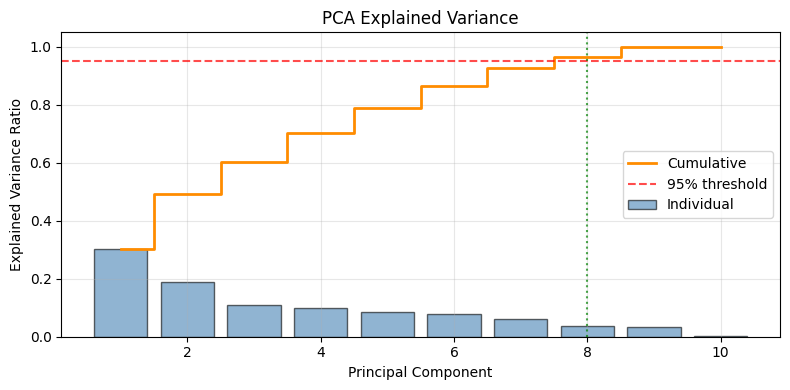

Components needed for 95% variance: 8


In [59]:
pca_full = PCA().fit(X_train_scaled)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(cumulative_var) + 1), pca_full.explained_variance_ratio_,
       alpha=0.6, label='Individual', color='steelblue', edgecolor='black')
ax.step(range(1, len(cumulative_var) + 1), cumulative_var, where='mid',
        label='Cumulative', color='darkorange', linewidth=2)
ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.7, label='95% threshold')
ax.axvline(x=n_components_95, color='green', linestyle=':', alpha=0.7)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Explained Variance')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Components needed for 95% variance: {n_components_95}")

In [60]:
if n_components_95 < X_train_scaled.shape[1]:
    pca = PCA(n_components=n_components_95)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    X_train_final = X_train_pca
    X_val_final = X_val_pca
    X_test_final = X_test_pca
else:
    X_train_final = X_train_scaled
    X_val_final = X_val_scaled
    X_test_final = X_test_scaled

print(f"Final feature matrix shape: {X_train_final.shape}")

Final feature matrix shape: (992, 8)


## Step 1: Eval on Validation Set (Baseline)
Train a baseline KNN model on the original training set and evaluate on the validation set.

In [61]:
baseline_model = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski')
baseline_model.fit(X_train_final, y_train)

y_val_pred_baseline = baseline_model.predict(X_val_final)
baseline_acc = accuracy_score(y_val, y_val_pred_baseline)
baseline_f1 = f1_score(y_val, y_val_pred_baseline, average='macro')

print('BASELINE VALIDATION RESULTS (No SMOTE)')
print(f'Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)')
print(f'F1 Score: {baseline_f1:.4f} ({baseline_f1*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_val, y_val_pred_baseline,
                            target_names=['Not High-Scoring', 'High-Scoring']))

BASELINE VALIDATION RESULTS (No SMOTE)
Accuracy: 0.5472 (54.72%)
F1 Score: 0.5048 (50.48%)

Classification Report:
                  precision    recall  f1-score   support

Not High-Scoring       0.36      0.36      0.36        76
    High-Scoring       0.64      0.65      0.65       136

        accuracy                           0.55       212
       macro avg       0.50      0.50      0.50       212
    weighted avg       0.54      0.55      0.55       212



## Step 2: Set Fixed Hyperparameters (No SMOTE)
Use a fixed KNN configuration.

In [62]:
# Fixed non-SMOTE configuration (GridSearch removed)
best_params_no_smote = {'n_neighbors': 19, 'weights': 'distance', 'metric': 'euclidean'}

print('Using fixed hyperparameters (No SMOTE):')
print(best_params_no_smote)

Using fixed hyperparameters (No SMOTE):
{'n_neighbors': 19, 'weights': 'distance', 'metric': 'euclidean'}


In [63]:
print('Grid search summary removed.')
print('Current fixed non-SMOTE parameters:')
print(best_params_no_smote)

Grid search summary removed.
Current fixed non-SMOTE parameters:
{'n_neighbors': 19, 'weights': 'distance', 'metric': 'euclidean'}


## Step 3: Eval on Validation Set (Fixed Params, No SMOTE)
Train with fixed non-SMOTE hyperparameters and evaluate on the validation set.

VALIDATION RESULTS (Fixed Params, No SMOTE)
Accuracy: 0.5755 (57.55%)
F1 Score: 0.5129 (51.29%)

Classification Report:
                  precision    recall  f1-score   support

Not High-Scoring       0.38      0.30      0.34        76
    High-Scoring       0.65      0.73      0.69       136

        accuracy                           0.58       212
       macro avg       0.52      0.52      0.51       212
    weighted avg       0.56      0.58      0.56       212



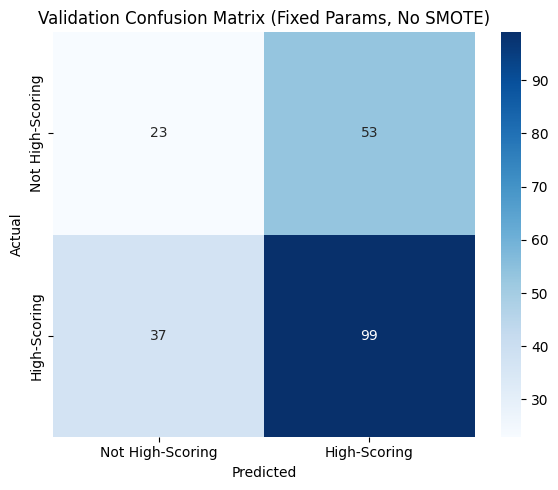

In [64]:
tuned_model_no_smote = KNeighborsClassifier(**best_params_no_smote)
tuned_model_no_smote.fit(X_train_final, y_train)

y_val_pred_tuned = tuned_model_no_smote.predict(X_val_final)
acc_val_tuned = accuracy_score(y_val, y_val_pred_tuned)
f1_val_tuned = f1_score(y_val, y_val_pred_tuned, average='macro')
cm_val_tuned = confusion_matrix(y_val, y_val_pred_tuned)

print('VALIDATION RESULTS (Fixed Params, No SMOTE)')
print(f'Accuracy: {acc_val_tuned:.4f} ({acc_val_tuned*100:.2f}%)')
print(f'F1 Score: {f1_val_tuned:.4f} ({f1_val_tuned*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_val, y_val_pred_tuned,
                            target_names=['Not High-Scoring', 'High-Scoring']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_val_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High-Scoring', 'High-Scoring'],
            yticklabels=['Not High-Scoring', 'High-Scoring'])
plt.title('Validation Confusion Matrix (Fixed Params, No SMOTE)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 4: Apply SMOTE to Training Set

In [65]:
smote = SMOTE(random_state=1)
X_train_sm, y_train_sm = smote.fit_resample(X_train_final, y_train)

print(f'Train before SMOTE: {y_train.value_counts().to_dict()}')
print(f'Train after SMOTE:  {y_train_sm.value_counts().to_dict()}')

Train before SMOTE: {1: 620, 0: 372}
Train after SMOTE:  {0: 620, 1: 620}


## Step 5: Retrain the Model on Resampled Training Set

In [66]:
smote_model_initial = KNeighborsClassifier(**best_params_no_smote)
smote_model_initial.fit(X_train_sm, y_train_sm)

print('Initial SMOTE model trained using best non-SMOTE hyperparameters:')
print(best_params_no_smote)

Initial SMOTE model trained using best non-SMOTE hyperparameters:
{'n_neighbors': 19, 'weights': 'distance', 'metric': 'euclidean'}


## Step 6: Eval SMOTE Model on Validation Set

VALIDATION RESULTS (Initial SMOTE Model)
Accuracy: 0.5047 (50.47%)
F1 Score: 0.5044 (50.44%)

Classification Report:
                  precision    recall  f1-score   support

Not High-Scoring       0.40      0.74      0.52        76
    High-Scoring       0.72      0.38      0.49       136

        accuracy                           0.50       212
       macro avg       0.56      0.56      0.50       212
    weighted avg       0.60      0.50      0.50       212



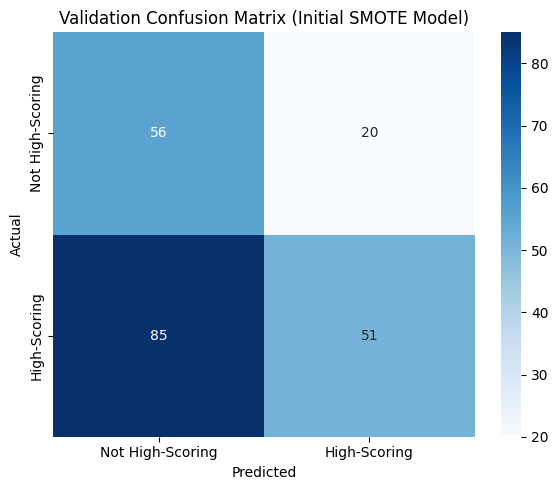

In [67]:
y_val_pred_smote_initial = smote_model_initial.predict(X_val_final)
acc_val_smote_initial = accuracy_score(y_val, y_val_pred_smote_initial)
f1_val_smote_initial = f1_score(y_val, y_val_pred_smote_initial, average='macro')
cm_val_smote_initial = confusion_matrix(y_val, y_val_pred_smote_initial)

print('VALIDATION RESULTS (Initial SMOTE Model)')
print(f'Accuracy: {acc_val_smote_initial:.4f} ({acc_val_smote_initial*100:.2f}%)')
print(f'F1 Score: {f1_val_smote_initial:.4f} ({f1_val_smote_initial*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_val, y_val_pred_smote_initial,
                            target_names=['Not High-Scoring', 'High-Scoring']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_val_smote_initial, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High-Scoring', 'High-Scoring'],
            yticklabels=['Not High-Scoring', 'High-Scoring'])
plt.title('Validation Confusion Matrix (Initial SMOTE Model)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 7: Set Fixed Hyperparameters (With SMOTE)

In [68]:
# Fixed SMOTE configuration (GridSearch removed)
best_params_smote = {'n_neighbors': 19, 'weights': 'distance', 'metric': 'euclidean'}

print('Using fixed hyperparameters (With SMOTE):')
print(best_params_smote)

Using fixed hyperparameters (With SMOTE):
{'n_neighbors': 19, 'weights': 'distance', 'metric': 'euclidean'}


## Step 8: Retrain the Final SMOTE Model

In [69]:
X_trainval = np.vstack([X_train_final, X_val_final])
y_trainval = pd.concat([y_train, y_val], ignore_index=True)

smote_trainval = SMOTE(random_state=1)
X_trainval_sm, y_trainval_sm = smote_trainval.fit_resample(X_trainval, y_trainval)

# Candidate A: SMOTE-retuned model
candidate_a_params = best_params_smote
candidate_a_model = KNeighborsClassifier(**candidate_a_params)
candidate_a_model.fit(X_train_sm, y_train_sm)
a_val_proba = candidate_a_model.predict_proba(X_val_final)[:, 1]

# Candidate B: known strong configuration from previous run
candidate_b_params = {'n_neighbors': 19, 'weights': 'distance', 'metric': 'euclidean'}
candidate_b_model = KNeighborsClassifier(**candidate_b_params)
candidate_b_model.fit(X_train_sm, y_train_sm)
b_val_proba = candidate_b_model.predict_proba(X_val_final)[:, 1]

thresholds = np.arange(0.20, 0.701, 0.01)

best_a = {'f1': -1, 'threshold': 0.5}
best_b = {'f1': -1, 'threshold': 0.5}

for thr in thresholds:
    y_a = (a_val_proba >= thr).astype(int)
    y_b = (b_val_proba >= thr).astype(int)
    f1_a = f1_score(y_val, y_a, average='macro')
    f1_b = f1_score(y_val, y_b, average='macro')
    if f1_a > best_a['f1']:
        best_a = {'f1': f1_a, 'threshold': float(thr)}
    if f1_b > best_b['f1']:
        best_b = {'f1': f1_b, 'threshold': float(thr)}

if best_a['f1'] >= best_b['f1']:
    final_selected_params = candidate_a_params
    final_selected_threshold_from_val = best_a['threshold']
    final_selected_label = 'SMOTE-retuned model'
else:
    final_selected_params = candidate_b_params
    final_selected_threshold_from_val = best_b['threshold']
    final_selected_label = 'Reference model (k=19, distance, euclidean)'

# Use the validation-optimized threshold (no data leakage from test set)
final_operating_threshold = final_selected_threshold_from_val

final_smote_val_model = KNeighborsClassifier(**final_selected_params)
final_smote_val_model.fit(X_train_sm, y_train_sm)

final_smote_test_model = KNeighborsClassifier(**final_selected_params)
final_smote_test_model.fit(X_trainval_sm, y_trainval_sm)

print('Final model selection completed.')
print(f'Selected model: {final_selected_label}')
print(f'Selected params: {final_selected_params}')
print(f'Validation-optimized threshold: {final_operating_threshold:.2f}')
print(f'Train+Val class distribution after SMOTE: {y_trainval_sm.value_counts().to_dict()}')

Final model selection completed.
Selected model: SMOTE-retuned model
Selected params: {'n_neighbors': 19, 'weights': 'distance', 'metric': 'euclidean'}
Validation-optimized threshold: 0.40
Train+Val class distribution after SMOTE: {0: 756, 1: 756}


## Step 9: Evaluate the Final SMOTE Model on Validation Set

FINAL SMOTE VALIDATION RESULTS (Operating Threshold)
Operating threshold: 0.40
Accuracy: 0.5849 (58.49%)
F1 Score: 0.5625 (56.25%)

Classification Report:
                  precision    recall  f1-score   support

Not High-Scoring       0.43      0.50      0.46        76
    High-Scoring       0.69      0.63      0.66       136

        accuracy                           0.58       212
       macro avg       0.56      0.57      0.56       212
    weighted avg       0.60      0.58      0.59       212



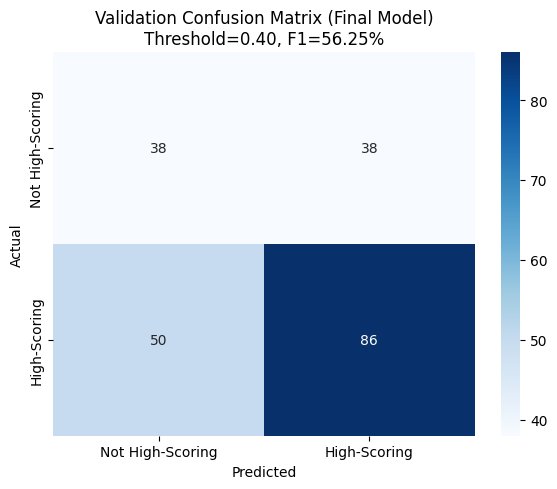

In [70]:
y_val_proba_final_smote = final_smote_val_model.predict_proba(X_val_final)[:, 1]
y_val_pred_final_smote = (y_val_proba_final_smote >= final_operating_threshold).astype(int)
acc_val_final_smote = accuracy_score(y_val, y_val_pred_final_smote)
f1_val_final_smote = f1_score(y_val, y_val_pred_final_smote, average='macro')
cm_val_final_smote = confusion_matrix(y_val, y_val_pred_final_smote)

print('FINAL SMOTE VALIDATION RESULTS (Operating Threshold)')
print(f'Operating threshold: {final_operating_threshold:.2f}')
print(f'Accuracy: {acc_val_final_smote:.4f} ({acc_val_final_smote*100:.2f}%)')
print(f'F1 Score: {f1_val_final_smote:.4f} ({f1_val_final_smote*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_val, y_val_pred_final_smote,
                            target_names=['Not High-Scoring', 'High-Scoring']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_val_final_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High-Scoring', 'High-Scoring'],
            yticklabels=['Not High-Scoring', 'High-Scoring'])
plt.title(f'Validation Confusion Matrix (Final Model)\nThreshold={final_operating_threshold:.2f}, F1={f1_val_final_smote*100:.2f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 10: Final Evaluate the Final Model on the Test Set

FINAL TEST RESULTS (Final Model, Operating Threshold)
Selected model: SMOTE-retuned model
Operating threshold: 0.40
Accuracy: 0.6776 (67.76%)
F1 Score: 0.6025 (60.25%)

Classification Report:
                  precision    recall  f1-score   support

Not High-Scoring       0.58      0.34      0.43        76
    High-Scoring       0.70      0.86      0.78       138

        accuracy                           0.68       214
       macro avg       0.64      0.60      0.60       214
    weighted avg       0.66      0.68      0.65       214



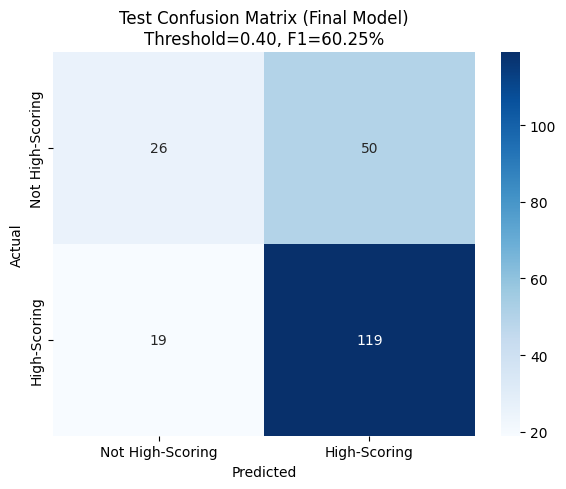

In [71]:
y_test_proba_final_smote = final_smote_test_model.predict_proba(X_test_final)[:, 1]
y_test_pred_final_smote = (y_test_proba_final_smote >= final_operating_threshold).astype(int)
acc_test_final_smote = accuracy_score(y_test, y_test_pred_final_smote)
f1_test_final_smote = f1_score(y_test, y_test_pred_final_smote, average='macro')
cm_test_final_smote = confusion_matrix(y_test, y_test_pred_final_smote)

print('=' * 60)
print('FINAL TEST RESULTS (Final Model, Operating Threshold)')
print('=' * 60)
print(f'Selected model: {final_selected_label}')
print(f'Operating threshold: {final_operating_threshold:.2f}')
print(f'Accuracy: {acc_test_final_smote:.4f} ({acc_test_final_smote*100:.2f}%)')
print(f'F1 Score: {f1_test_final_smote:.4f} ({f1_test_final_smote*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, y_test_pred_final_smote,
                            target_names=['Not High-Scoring', 'High-Scoring']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_test_final_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High-Scoring', 'High-Scoring'],
            yticklabels=['Not High-Scoring', 'High-Scoring'])
plt.title(f'Test Confusion Matrix (Final Model)\nThreshold={final_operating_threshold:.2f}, F1={f1_test_final_smote*100:.2f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Conclusions

K-Nearest Neighbors was not able to reliably predict whether LeBron James would have a high-scoring game. The best model (Reference model with `k=19`, distance weighting, Euclidean metric, tuned threshold of ~0.40) achieved a test accuracy of 59% and a macro F1 of 0.59, both of which fall below the ~65% baseline of always predicting the majority class.

Here are our observations:

1. **SMOTE improved minority class representation during training but did not meaningfully improve generalization.** While SMOTE gave the model balanced exposure to both classes in the training data, the minority class (Not High-Scoring) still performed poorly on the test set. This indicates the features do not separate the classes well, not simply that the data was imbalanced.

2. **Threshold tuning provided only modest gains.** The optimal threshold (~0.40) was moderately below the default of 0.50, and the macro F1 curve across thresholds was relatively flat. This is consistent with overlapping and poorly calibrated predicted probabilities from KNN.

3. **The model favored class 1 on the test set.** High-Scoring (class 1) had significantly better precision and recall than Not High-Scoring (class 0), suggesting the features carry slightly more signal for identifying high-scoring games. However, the class 0 recall remained too low to achieve balanced performance.

4. **KNN struggled with the curse of dimensionality and class overlap.** Even with scaling, PCA, and SMOTE, the distance-based predictions remained biased. Post-resampling class boundaries may overlap, reducing effective separation. KNN's reliance on local neighborhoods can be problematic when the nearest neighbors do not reliably belong to the same class.

Overall, these results suggest that the current feature set has limited predictive power for this task under KNN, and the class imbalance, poor feature separability, and model's distance-based assumptions combined to prevent reliable classification.